In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torchvision
import torch.nn.functional as F
import torch.optim as optim

import splitfolders
from torchvision import datasets
from torchvision.transforms import v2
from torch.utils.data import DataLoader

https://docs.google.com/document/d/1Cl8MROxG-uxCfVTFjVeJALk833X7vGhShxwXkHrDeN0/edit?tab=t.0
 

1. Splitting the Data into Train Test AND preanalysis in dimensions

In [3]:
#splitfolders.ratio("/home/dghtan/Projects/Pokemon-Image-Prediction/PokemonData", output = "/home/dghtan/Projects/Pokemon-Image-Prediction/PokemonDataTrainTest", seed = 1337, ratio = (0.8, 0 , 0.2), group_prefix= None, move = False)


In [ ]:
raw_train_data = datasets.ImageFolder(root = "/home/dghtan/Projects/Pokemon-Image-Prediction/OrganizedData/PokemonDataTrainTest/train", transform = None)


In [ ]:
print(f"Number of images: {len(raw_train_data)}")

first_image, first_label = raw_train_data[0]
#In form of tupple: (<PIL.Image.Image image mode=RGB size=229x220 at 0x70585919F5F0>, 0)
#Image details, and class/label
print(f"Dimensions of first image (W, H): {first_image.size}")


Number of images: 5391
Dimensions of first image (W, H): (229, 220)
(<PIL.Image.Image image mode=RGB size=249x240 at 0x7069A73EE810>, 1)


In [6]:
dimensions_df = pd.DataFrame(columns = ["Width", "Height"])
# dimensions_df.loc[len(dimensions_df)] = raw_train_data[0][0].size
for image in raw_train_data:
  dimensions_df.loc[len(dimensions_df)] = image[0].size


In [7]:
dimensions_df.head(10)

,Width,Height
0,229,220
1,422,422
2,723,723
3,597,597
4,170,170
5,226,238
6,280,279
7,711,704
8,552,552
9,218,210


<function matplotlib.pyplot.show(close=None, block=None)>

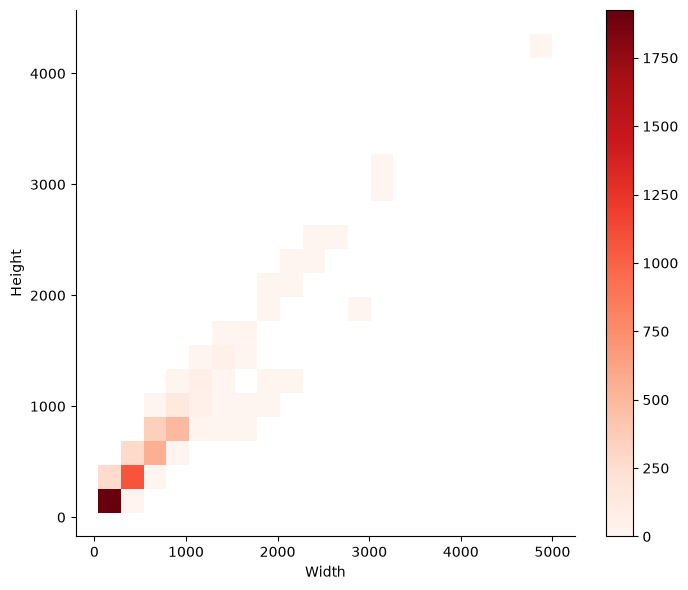

In [8]:
#Check that the images are mostly square
sns.displot(data= dimensions_df,
    x="Width",
    y="Height",
    kind="hist",  # Tells Seaborn to make a histogram grid
    cbar=True,  # Shows the color bar scale for counts
    cmap="Reds",  # Darker blue means more observations
    bins=20,  # Adjusts the grid resolution (square sizes)
    height=6,
    aspect=1.2)
plt.show

In [9]:
meadian_width = dimensions_df["Width"].median()
median_height = dimensions_df["Height"].median()
print(f"Median Height: {median_height}")
print(f"Median Width: {meadian_width}")

#Round to closest mutliple of 32: 352 -> (32*11) for cleaner computations


Median Height: 351.0
Median Width: 351.0


In [10]:
#https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html

#Put later: 
#v2.Normalize(mean[m1, m2, m3]], std[std1, std2, std3]])

#1.   ToImage first into integers rather than image object 
#1.5  antialias, smooths out lost pixels in diagonals
#2    Do Resizing and Rotations easier on integers plus uses GPU instead
#3    Turn into floats as doing augmentation on floats are much harder 
#3.5  scale turns the image pixels from [0,255] -> [0,1]
#4.   Should Normalize later
train_transform = v2.Compose([
  v2.ToImage(),
  v2.Resize((352,352), antialias = True),
  v2.RandomRotation(20),
  v2.ToDtype(torch.float32, scale = True),
])

test_transform = v2.Compose([
  v2.ToImage(),
  v2.Resize((352,352), antialias = True),
  v2.RandomRotation(20),
  v2.ToDtype(torch.float32, scale = True),
])

train_data = datasets.ImageFolder(root = "/home/dghtan/Projects/Pokemon-Image-Prediction/PokemonDataTrainTest/train", transform= train_transform)

test_data = datasets.ImageFolder(root = "/home/dghtan/Projects/Pokemon-Image-Prediction/PokemonDataTrainTest/test", transform = test_transform)


batch_size = 8
#pin_memory = True (Use with stronger gpus)
train_loader = DataLoader(
  dataset = train_data,
  batch_size= batch_size,
  shuffle = True,
  num_workers= 2,
  drop_last= False
)

test_loader = DataLoader(
  dataset = test_data,
  batch_size= batch_size,
  shuffle= False,
  num_workers= 2,
  drop_last= False
)

Looking at the images

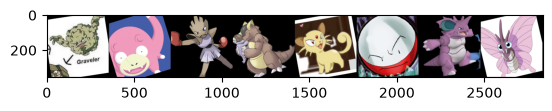

TRUE LABEL:  Graveler Slowpoke Hitmonchan Kangaskhan Persian Electrode Nidoking Venomoth


In [97]:
def imshow(img):
    # img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)
# print(images[4].size())
# show images
def showImBatch(image, label):
    imshow(torchvision.utils.make_grid(image))
    # print labels
    print('TRUE LABEL: ', ' '.join(f'{train_data.classes[label[j]]:5s}' for j in range(batch_size)))
showImBatch(images, labels)


In [ ]:
print(f"Number of classes: {len(raw_train_data.classes)}")
print(raw_train_data.classes[0])

gen1_pokemon = {
    "Abra", "Aerodactyl", "Alakazam", "Arbok", "Arcanine", "Articuno",
    "Beedrill", "Bellsprout", "Blastoise", "Bulbasaur", "Butterfree",
    "Caterpie", "Chansey", "Charizard", "Charmander", "Charmeleon",
    "Clefable", "Clefairy", "Cloyster", "Cubone", "Dewgong", "Diglett",
    "Ditto", "Dodrio", "Doduo", "Dragonair", "Dragonite", "Dratini",
    "Drowzee", "Dugtrio", "Eevee", "Ekans", "Electabuzz", "Electrode",
    "Exeggcute", "Exeggutor", "Farfetchd", "Fearow", "Flareon",
    "Gastly", "Gengar", "Geodude", "Gloom", "Golbat", "Goldeen",
    "Golduck", "Golem", "Graveler", "Grimer", "Growlithe", "Gyarados",
    "Haunter", "Hitmonchan", "Hitmonlee", "Horsea", "Hypno", "Ivysaur",
    "Jigglypuff", "Jolteon", "Jynx", "Kabuto", "Kabutops", "Kadabra", "Kakuna",
    "Kangaskhan", "Kingler", "Koffing", "Krabby", "Lapras", "Lickitung",
    "Machamp", "Machoke", "Machop", "Magikarp", "Magmar", "Magnemite",
    "Magneton", "Mankey", "Marowak", "Meowth", "Metapod", "Mew",
    "Mewtwo", "Moltres", "MrMime", "Muk", "Nidoking", "Nidoqueen",
    "Nidoran-f", "Nidoran-m", "Nidorina", "Nidorino", "Ninetales", "Oddish",
    "Omanyte", "Omastar", "Onix", "Paras", "Parasect", "Persian",
    "Pidgeot", "Pidgeotto", "Pidgey", "Pikachu", "Pinsir", "Poliwag",
    "Poliwhirl", "Poliwrath", "Ponyta", "Porygon", "Primeape", "Psyduck",
    "Raichu", "Rapidash", "Raticate", "Rattata", "Rhydon", "Rhyhorn",
    "Sandshrew", "Sandslash", "Scyther", "Seadra", "Seaking", "Seel",
    "Shellder", "Slowbro", "Slowpoke", "Snorlax", "Spearow", "Squirtle",
    "Starmie", "Staryu", "Tangela", "Tauros", "Tentacool", "Tentacruel",
    "Vaporeon", "Venomoth", "Venonat", "Venusaur", "Victreebel", "Vileplume",
    "Voltorb", "Vulpix", "Wartortle", "Weedle", "Weepinbell", "Weezing",
    "Wigglytuff", "Zapdos", "Zubat"
}
print(gen1_pokemon.difference(train_data.classes))

print(set(train_data.classes).difference(gen1_pokemon))

print(len(gen1_pokemon))

Number of classes: 150
Abra
{'Nidoran♀', 'Nidoran♂'}
{'Alolan Sandslash'}
151


Missing Nidoran of both genders
Extra - Alolan Sandslash

2. Building the CNN

In [ ]:
#352 x 352
#Aim to 256 - 4096 features
class Net(nn.Module):
  #, conv, pool, fc
  def __init__(self):
    super().__init__()

    # (# channels, #filters/output channels, square filter size)
    self.conv1 = nn.Conv2d(3,6,5)
    #Takes the max value of the 2x2 in the filtes in conv
    self.pool = nn.MaxPool2d(2,2)

    self.conv2 = nn.Conv2d(6,12,5)


    self.fc1 = nn.Linear(12 * 85 * 85, 900)
    self.fc2 = nn.Linear(900, 300)
    self.fc3 = nn.Linear(300, 150)


  def forward(self, x):
    x = F.relu(self.conv1(x))
    x = self.pool(x)

    x = F.relu(self.conv2(x))
    x = self.pool(x)
    x = torch.flatten(x,1)

    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)

    return x

net = Net()

3. Defining loss function

In [81]:
criterion = nn.CrossEntropyLoss()

#-ln( e^(output of right class ) / sum(e^(output of other classes)))
#Sum this for all images in the batch

optimizer = optim.SGD(net.parameters(), lr = 0.001, momentum= 0.9)

4. Trainning the CNN

In [83]:
for epoch in range(2):
  running_loss = 0.0

  #Loop through the batches in train loader
  for i, data in enumerate(train_loader,0):
    #Get the image details and the label its classified under for the BATCH?
    inputs, labels = data

    #Reset the gradients from stacking onto eachother
    optimizer.zero_grad()

    #Forward, backward, optimizing step
    outputs = net(inputs)
    loss = criterion(outputs, labels )
    loss.backward()
    optimizer.step()
    

    
print('Finished Training')

Finished Training


5. Test?

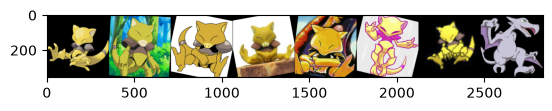

TRUE LABEL:  Abra  Abra  Abra  Abra  Abra  Abra  Abra  Aerodactyl
Predicted:   Hypno Hypno Hypno Magmar Kakuna Magikarp Kakuna Alolan Sandslash


In [98]:
test_dataiter = iter(test_loader)
images, labels = next(test_dataiter)

showImBatch(images, labels)

outputs = net(images)

#torch max returns value/score then prediction index which we want
_, predicted = torch.max(outputs, 1)

print('Predicted:  ' ,' '.join(f'{test_data.classes[predicted[j]]:5s}' for j in range(batch_size)))

#print(' '.join(f'{train_data.classes[label[j]]:5s}' for j in range(batch_size)))
